<a href="https://colab.research.google.com/github/Aryamaan777/Finance/blob/AssetPricingModels/AssetPricingModels/Fama_French_3_Factor_Model_%2B_Kalman_FF3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install getFamaFrenchFactors

In [ ]:
!pip install pykalman

In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf

import matplotlib.pyplot as plt

import statsmodels.api as sm

import getFamaFrenchFactors as gff
from pykalman import KalmanFilter

In [ ]:
# Monthly Fama-French 3 factors (MKT-RF, SMB, HML, RF)
ff3 = gff.famaFrench3Factor(frequency='m')

ff3['date_ff_factors'] = pd.to_datetime(ff3['date_ff_factors'])
ff3.set_index('date_ff_factors', inplace=True)
ff3.index = ff3.index.to_period('M')

print(ff3.tail())

                 Mkt-RF     SMB     HML      RF
date_ff_factors                                
2025-07          0.0198  0.0026 -0.0127  0.0034
2025-08          0.0184  0.0387  0.0442  0.0038
2025-09          0.0339 -0.0185 -0.0105  0.0033
2025-10          0.0196 -0.0055 -0.0309  0.0037
2025-11         -0.0013  0.0038  0.0376  0.0030


In [ ]:
# Download your stock data monthly
ticker = "AAPL"
prices = yf.download(ticker, start="2010-01-01", end="2024-01-01", interval="1mo", auto_adjust = False)["Adj Close"]

# Compute monthly returns
returns = prices.pct_change().dropna()
# returns.reset_index(inplace=True)
returns.rename(columns={"AAPL": "ret"}, inplace=True)

# Step 1: Ensure datetime index
returns.index = pd.to_datetime(returns.index)

# Step 2: Convert to monthly periods
returns.index = returns.index.to_period("M")

returns.head()

[*********************100%***********************]  1 of 1 completed


Ticker,ret
Date,
2010-02,0.065396
2010-03,0.148470
2010-04,0.111021
2010-05,-0.016125
2010-06,-0.020826


In [ ]:
data = returns.join(ff3, how="inner")
data.dropna(inplace=True)

data.head()

,ret,Mkt-RF,SMB,HML,RF
2010-02,0.065396,0.0339,0.0118,0.0318,0.0000
2010-03,0.148470,0.0630,0.0146,0.0219,0.0001
2010-04,0.111021,0.0199,0.0484,0.0296,0.0001
2010-05,-0.016125,-0.0790,0.0013,-0.0248,0.0001
2010-06,-0.020826,-0.0556,-0.0179,-0.0473,0.0001


In [ ]:
data["Excess"] = data["ret"] - data["RF"]
data.head()

,ret,Mkt-RF,SMB,HML,RF,Excess
2010-02,0.065396,0.0339,0.0118,0.0318,0.0000,0.065396
2010-03,0.148470,0.0630,0.0146,0.0219,0.0001,0.148370
2010-04,0.111021,0.0199,0.0484,0.0296,0.0001,0.110921
2010-05,-0.016125,-0.0790,0.0013,-0.0248,0.0001,-0.016225
2010-06,-0.020826,-0.0556,-0.0179,-0.0473,0.0001,-0.020926


In [ ]:
X = data[["Mkt-RF", "SMB", "HML"]]
y = data["Excess"]

# add constant for alpha term
X = sm.add_constant(X)

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 Excess   R-squared:                       0.458
Model:                            OLS   Adj. R-squared:                  0.448
Method:                 Least Squares   F-statistic:                     45.83
Date:                Wed, 14 Jan 2026   Prob (F-statistic):           1.56e-21
Time:                        06:20:16   Log-Likelihood:                 239.87
No. Observations:                 167   AIC:                            -471.7
Df Residuals:                     163   BIC:                            -459.3
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0098      0.005      2.108      0.0

From the regression output:

* const → α (intercept) = abnormal return not explained by the factors
* Mkt-RF coefficient → market exposure
* SMB coefficient → exposure to size premium
* HML coefficient → exposure to value premium

<Axes: title={'center': 'Rolling Fama-French 3-Factor Betas'}>

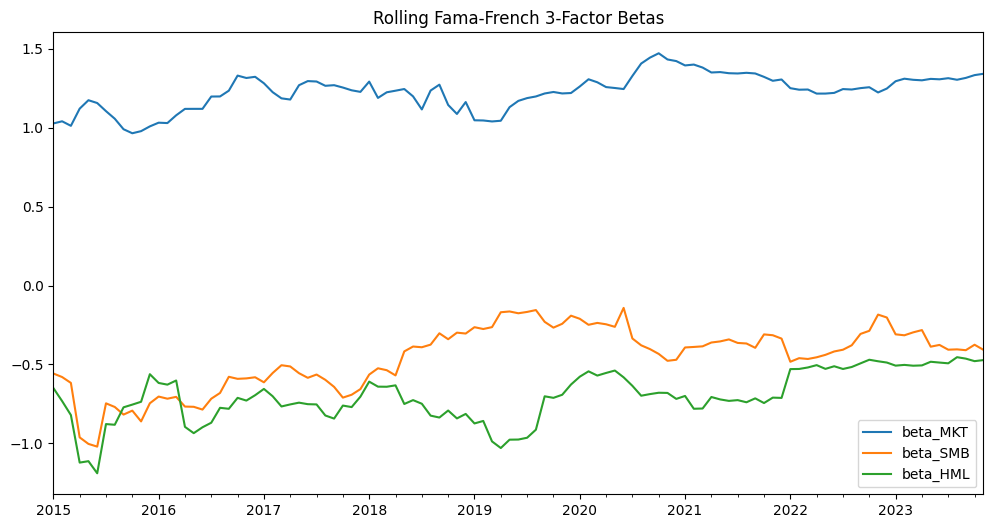

In [ ]:
window = 60  # 5 years of monthly data
dates = []
betas_mkt, betas_smb, betas_hml = [], [], []

for i in range(window, len(data)):
    sub = data.iloc[i-window:i]
    X_sub = sm.add_constant(sub[["Mkt-RF", "SMB", "HML"]])
    y_sub = sub["Excess"]
    reg = sm.OLS(y_sub, X_sub).fit()

    betas_mkt.append(reg.params["Mkt-RF"])
    betas_smb.append(reg.params["SMB"])
    betas_hml.append(reg.params["HML"])
    dates.append(sub.index[-1])

rolling_betas = pd.DataFrame({
    "beta_MKT": betas_mkt,
    "beta_SMB": betas_smb,
    "beta_HML": betas_hml
}, index=dates)

rolling_betas.plot(figsize=(12, 6), title="Rolling Fama-French 3-Factor Betas")

# Why FF3 Is Better Than CAPM (Critique)

The Fama-French 3-factor model improves on CAPM by addressing empirical anomalies:

✔ Size effect: Small caps historically outperform big caps<br>
✔ Value effect: High book-to-market stocks outperform low book-to-market<br>
✔ These factors help explain cross-section return patterns CAPM misses<br>

Yet it still has limitations:

❌ No momentum factor (Carhart adds this)<br>
❌ Doesn’t address time-varying betas<br>
❌ Still linear and single-period

# KALMAN FF3

In [ ]:
# Ensure numeric columns
for col in ['Excess','Mkt-RF','SMB','HML']:
    data[col] = pd.to_numeric(data[col], errors='coerce')

# Drop any NaNs just in case
data = data.dropna()

In [ ]:
y = data['Excess'].to_numpy(dtype=float)       # 1D array
factors = data[['Mkt-RF','SMB','HML']].to_numpy(dtype=float)  # 2D array

In [ ]:
kf = KalmanFilter(
    n_dim_obs=1,
    n_dim_state=4,               # alpha + 3 betas
    transition_matrices=np.eye(4),
    transition_covariance=np.diag([1e-6,1e-4,1e-4,1e-4]),
    observation_covariance=1e-3,
    initial_state_mean=np.array([0,1,0,0], dtype=float),
    initial_state_covariance=np.eye(4)
)

In [ ]:
state_means = []
state_covs = []

state_mean = kf.initial_state_mean
state_cov = kf.initial_state_covariance

for t in range(len(y)):
    obs_matrix_t = np.array([[1.0, factors[t,0], factors[t,1], factors[t,2]]], dtype=float)
    state_mean, state_cov = kf.filter_update(
        filtered_state_mean=state_mean,
        filtered_state_covariance=state_cov,
        observation=np.array([y[t]], dtype=float),
        observation_matrix=obs_matrix_t
    )
    state_means.append(state_mean)
    state_covs.append(state_cov)

state_means = np.array(state_means)
state_covs = np.array(state_covs)

In [ ]:
if isinstance(data.index, pd.PeriodIndex):
    safe_index = data.index.to_timestamp()
else:
    # Fallback: Convert to string if it's some other weird object type
    safe_index = data.index.astype(str)

In [ ]:
alpha_kf = pd.Series(state_means[:,0], index=safe_index)
beta_mkt_kf = pd.Series(state_means[:,1], index=safe_index)
beta_smb_kf = pd.Series(state_means[:,2], index=safe_index)
beta_hml_kf = pd.Series(state_means[:,3], index=safe_index)

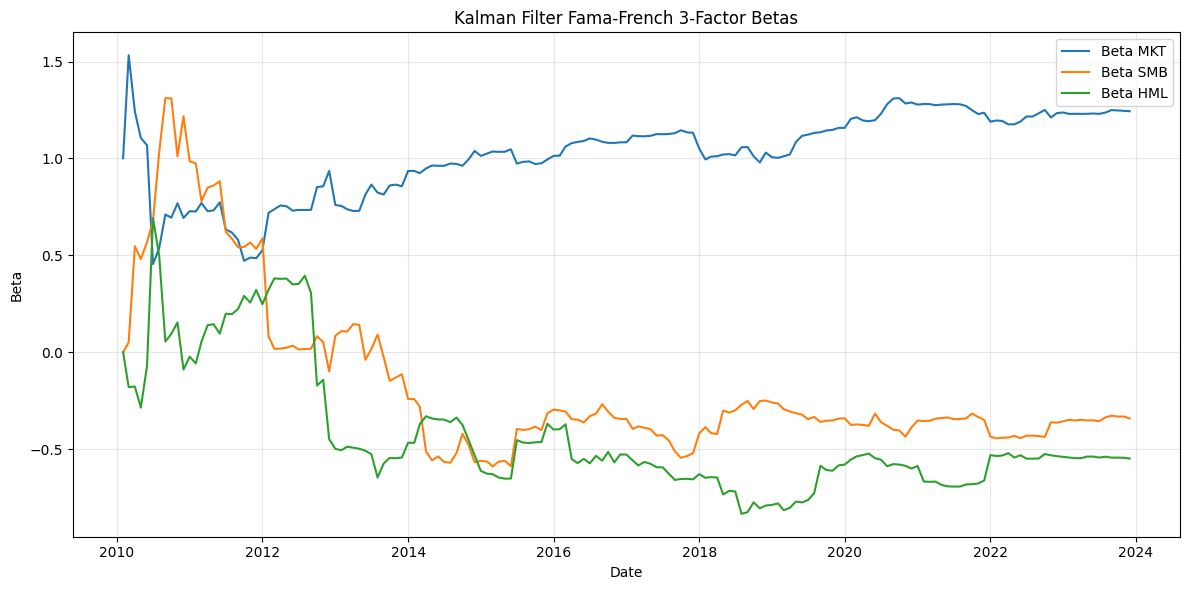

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(beta_mkt_kf.index, beta_mkt_kf.values, label="Beta MKT")
plt.plot(beta_smb_kf.index, beta_smb_kf.values, label="Beta SMB")
plt.plot(beta_hml_kf.index, beta_hml_kf.values, label="Beta HML")
plt

plt.title("Kalman Filter Fama-French 3-Factor Betas")
plt.xlabel("Date")
plt.ylabel("Beta")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 1. CAPM (Capital Asset Pricing Model)<br>
The "Grandfather" of Models (1960s)<br>
CAPM is the simplest theory of how stocks are priced. It argues that there is only one reason a stock should give you higher returns: Market Risk.<br>
The Big Idea: You don't get paid for taking risks that can be diversified away (like a CEO quitting). You only get paid for taking risks that affect the whole economy (like a recession).<br>
The Metric ($\beta$): Beta measures how sensitive a stock is to the overall market.<br>
  * $\beta = 1$: Moves exactly with the market.
  * $\beta = 2$: Moves 2x as much as the market (High Risk/High Reward).
  * The Flaw: It's too simple. In reality, some stocks (like Small Caps) outperform the market consistently, even if they have low Beta. CAPM cannot explain this "Alpha."

# 2. Fama-French 3-Factor Model
The "Upgrade" (1990s) - Eugene Fama and Kenneth French looked at CAPM and said, "This beta number explains about 70% of returns. What explains the rest?"<br>

They found two consistent patterns that CAPM missed.
* Factor 1: Market Risk (Mkt-RF): The same as CAPM.
* Factor 2: Size (SMB - "Small Minus Big"): Historically, Small Cap companies outperform Large Cap companies.
* Factor 3: Value (HML - "High Minus Low"): Historically, Value stocks (cheap relative to book value) outperform Growth stocks.

**Why use it?<br>**
If you analyze a portfolio with CAPM, it might look like the manager is a genius (high Alpha). But if you analyze it with Fama-French, you might realize the manager is just buying risky Small-Cap Value stocks.<br>
The "Alpha" vanishes into "Factor Exposure."

# 3. The Kalman Filter
The "Engine" (Dynamic Estimation)<br>
CAPM and Fama-French are theories. The Kalman Filter is a mathematical tool. Standard statistics (like the OLS regression you used earlier) assumes that Beta is constant forever. It assumes Apple is exactly as risky in 2024 as it was in 2010. We know that is false.<br>

What it does: The Kalman Filter is a recursive algorithm that updates its estimate in real-time. It treats Beta not as a fixed number, but as a "hidden state" that drifts over time.<br>

How it works:
  * Predict: "Based on yesterday, I think Beta is 1.2 today.
  * "Measure: "New data came in! The stock moved less than I expected.
  * "Update: "Okay, let's nudge Beta down to 1.18 for tomorrow."